In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from tqdm.auto import tqdm
import fisherunlearn

import os, pickle

/home/lorenzo/projects/FedUnlearn-PE/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fisherunlearn.set_device(DEVICE)

target_client = 0
train_epochs = 6
retrain_epochs = 1

test_path = r"stat_tests/EXPERIMENTS/MNIST_pref"
iteration = 0
test_iter_path = os.path.join(test_path, f"iter_{iteration}")
os.makedirs(test_iter_path, exist_ok=True)

In [4]:
from torch import nn

class FLNet(nn.Sequential):
            def __init__(self):
                super(FLNet, self).__init__(
                    nn.Conv2d(1, 32, 5, padding=2),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                    nn.Conv2d(32, 64, 5, padding=2),
                    nn.ReLU(),
                    nn.MaxPool2d(2),
                    nn.Flatten(),
                    nn.Linear(64 * 7 * 7, 512),
                    nn.ReLU(),
                    nn.Linear(512, 10)
                    )

In [5]:
from torchvision import transforms
from torchvision.datasets import MNIST

from fisherunlearn.clients_utils import split_dataset_by_class_distribution
import numpy as np

num_clients = 10
num_classes = 10


transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# class_distribution = np.ones((num_clients, num_classes)) / num_classes
# clients_subsets = split_dataset_by_class_distribution(train_dataset, class_distribution)

In [6]:
num_clients = 10
num_classes = 10

num_common_classes = num_classes - num_clients
p_common = 1 / (num_common_classes + num_clients)
p_preferred = p_common * num_clients
class_distribution = np.zeros((num_clients, num_classes))
for i in range(num_clients):
    for j in range(num_common_classes):
        class_distribution[i, j] = p_common
    class_distribution[i, num_common_classes+i] = p_preferred
clients_subsets = split_dataset_by_class_distribution(train_dataset, class_distribution)

In [7]:
client_indices = [subset.indices for subset in clients_subsets]
with open(os.path.join(test_path, "clients_indices.pkl"), 'wb') as f:
    pickle.dump(client_indices, f)

labels = {
    'train': [label for _, label in train_dataset],
    'test': [label for _, label in test_dataset]
}
with open(os.path.join(test_path, "labels.pkl"), 'wb') as f:
    pickle.dump(labels, f)

In [8]:
from fisherunlearn.clients_utils import concatenate_subsets
from torch.utils.data import DataLoader

learning_rate = 0.01
momentum = 0.9



def simple_trainer(model, loss_fn, train_subsets, val_subsets, epochs):
    device = DEVICE
    model.train()

    train_dataset = concatenate_subsets(train_subsets)
    val_dataset = concatenate_subsets(val_subsets)

    dataloader = DataLoader(train_dataset, TRAIN_BATCH_SIZE, shuffle=True)
    val_dataloader = DataLoader(val_dataset, EVAL_BATCH_SIZE, shuffle=False)
    model.to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum)

    for epoch in tqdm(range(epochs), desc="Training", unit="epoch", leave=False):     
        loss = None
        loss_accum = 0.0
        n_batches = 0
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            loss_accum += loss.item()
            n_batches += 1
        val_loss_accum = 0.0
        val_n_batches = 0
        for val_inputs, val_targets in val_dataloader:
            val_inputs, val_targets = val_inputs.to(device), val_targets.to(device)
            with torch.no_grad():
                val_outputs = model(val_inputs)
                val_loss = loss_fn(val_outputs, val_targets)
                val_loss_accum += val_loss.item()
                val_n_batches += 1
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss_accum / n_batches}, Val Loss: {val_loss_accum / val_n_batches}")

    model.eval()
    return model.cpu()

In [9]:
def logit_margin(z: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    """
    z: (B, C) logits
    y: (B,) int64 labels
    returns: (B,) margins z_y - max_{j!=y} z_j
    """
    # true class logit
    zy = z.gather(1, y.unsqueeze(1)).squeeze(1)  # (B,)

    # top-2 logits and their class indices
    top2_vals, top2_idx = z.topk(k=2, dim=1)     # (B,2), (B,2)

    # best "other" logit: if top1 is true class -> take top2 else top1
    top1_is_true = (top2_idx[:, 0] == y)
    z_other = torch.where(top1_is_true, top2_vals[:, 1], top2_vals[:, 0])  # (B,)

    return zy - z_other

def evaluate_model(model, dataset):
    dataloader = DataLoader(dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False)
    preds = []
    margins = []
    model.to(DEVICE)
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            output = model(images)
            batch_preds = torch.argmax(output, dim=1)
            preds.append(batch_preds.cpu())
            batch_margins = logit_margin(output, labels)
            margins.append(batch_margins.cpu())
    model.cpu()
    return {
        "pred": torch.cat(preds).numpy(),
        "loss": torch.cat(margins).numpy()
    }

In [10]:
from fisherunlearn.clients_utils import random_split_subset
from torch.utils.data import Subset

complete_dataset = torch.utils.data.ConcatDataset([train_dataset, test_dataset])

target_subset = clients_subsets[target_client]
non_target_subsets = [subset for i, subset in enumerate(clients_subsets) if i != target_client]

model_class = lambda: FLNet()
loss_class = lambda: nn.CrossEntropyLoss()
trainer_function = simple_trainer

num_total_params = sum(p.numel() for p in model_class().parameters())

eval_split_ratio = 0.1
shadow_out_subsets = []
eval_subsets = []
for subset in non_target_subsets:
    n_eval = int(len(subset) * eval_split_ratio)
    n_train = len(subset) - n_eval
    train, eval = random_split_subset(subset, [n_train, n_eval])
    shadow_out_subsets.append(train)
    eval_subsets.append(eval)

retrain_subsets = shadow_out_subsets
eval_subsets = eval_subsets

train_subsets = shadow_out_subsets + [target_subset]

shadow_in_subsets = [Subset(complete_dataset, subset.indices) for subset in train_subsets]
shadow_in_subsets.append(Subset(complete_dataset, list(range(len(train_dataset), len(complete_dataset)))))  # add test dataset as last subset

trained_model = trainer_function(
    model_class(), loss_class(), train_subsets, eval_subsets,
    train_epochs
)

print("Training shadow_out model...") 
shadow_out_model = trainer_function(
    model_class(), loss_class(), shadow_out_subsets, eval_subsets,
    train_epochs
)

print("Training shadow_in model...")
shadow_in_model = trainer_function(
    model_class(), loss_class(), shadow_in_subsets, eval_subsets,
    train_epochs
)

Training:  17%|█▋        | 1/6 [00:14<01:13, 14.63s/epoch]

Epoch 1/6, Loss: 0.3751690973349186, Val Loss: 0.09608948756104861


Training:  33%|███▎      | 2/6 [00:26<00:51, 12.80s/epoch]

Epoch 2/6, Loss: 0.06777067099085049, Val Loss: 0.06762478676123115


Training:  50%|█████     | 3/6 [00:37<00:36, 12.20s/epoch]

...

Training:  67%|██████▋   | 4/6 [00:58<00:29, 14.84s/epoch]

Epoch 4/6, Loss: 0.03192797268576246, Val Loss: 0.04934920935939329


Training:  83%|████████▎ | 5/6 [01:13<00:14, 14.68s/epoch]

Epoch 5/6, Loss: 0.02542737903322318, Val Loss: 0.04875132897331451


Epoch 6/6, Loss: 0.02034483086804514, Val Loss: 0.04394874930007157


In [11]:
print("Computing initial evaluation results...")

init_eval_test_results = {
    "trained": evaluate_model(trained_model, test_dataset),
    "shadow_out": evaluate_model(shadow_out_model, test_dataset),
    "shadow_in": evaluate_model(shadow_in_model, test_dataset)
}
init_eval_train_results = {
    "trained": evaluate_model(trained_model, train_dataset),
    "shadow_out": evaluate_model(shadow_out_model, train_dataset),
    "shadow_in": evaluate_model(shadow_in_model, train_dataset)
}

with open(os.path.join(test_iter_path, "initial_eval_test_results.pkl"), 'wb') as f:
        pickle.dump(init_eval_test_results, f)
with open(os.path.join(test_iter_path, "initial_eval_train_results.pkl"), 'wb') as f:
    pickle.dump(init_eval_train_results, f) 

Computing initial evaluation results...


In [12]:
# from fisherunlearn import compute_client_information_nd

# fisherunlearn.set_info_batch_size(128)

# print("Computing information...")
# client_information = compute_client_information_nd(target_client, trained_model, loss_class(), clients_subsets)

In [ ]:
from new_method import estimate_diag_commuting_backpack

batch_size = 128

total_loader = DataLoader(clients_subsets[0].dataset, batch_size, shuffle=True)
client_laoder = DataLoader(clients_subsets[target_client], batch_size, shuffle=True)
client_information = estimate_diag_commuting_backpack(trained_model.to("cuda"), total_loader, client_laoder, loss_class(), 10, "cuda", 5 )["diag_by_name"]

Finished iter


800


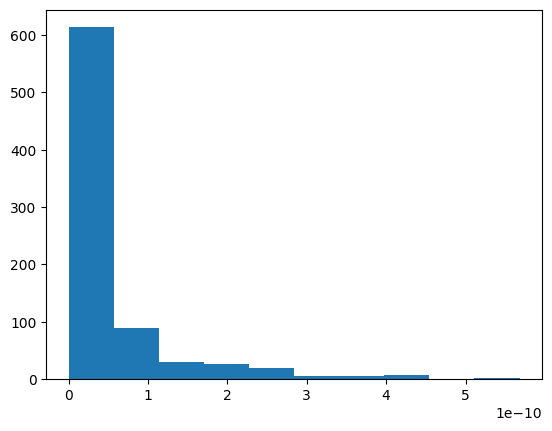

32


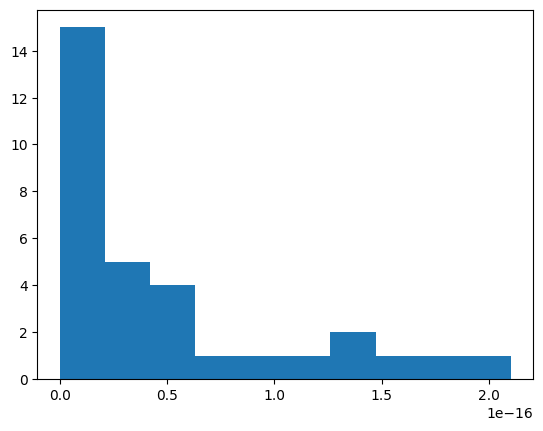

51200


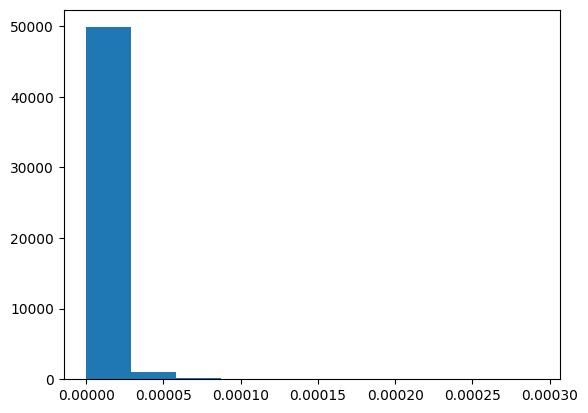

64


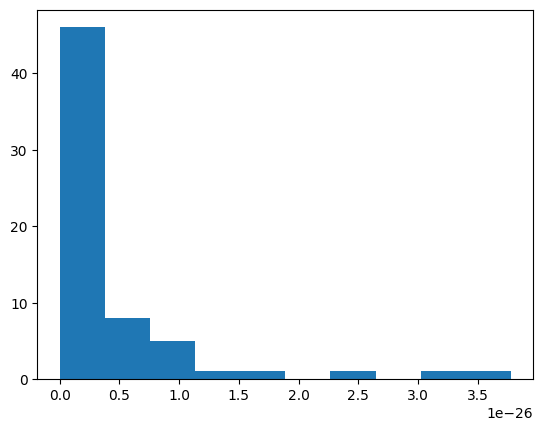

1594199


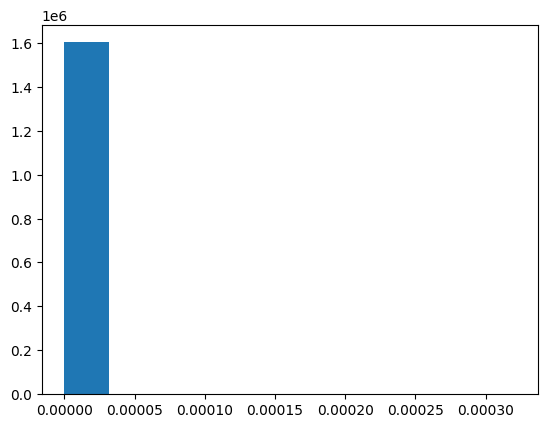

512


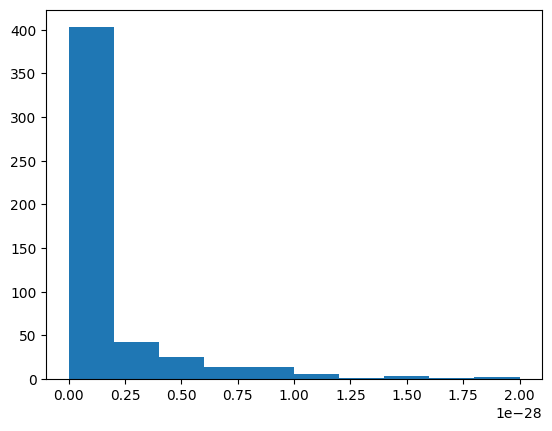

5120


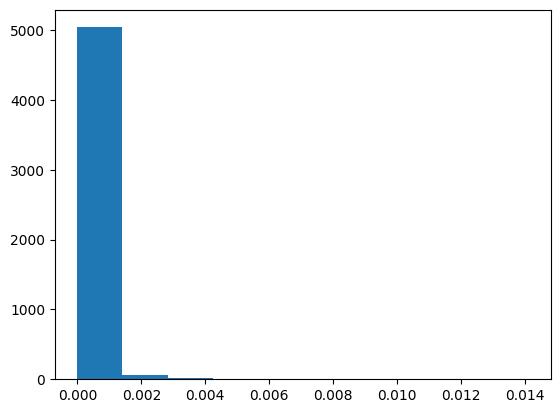

10


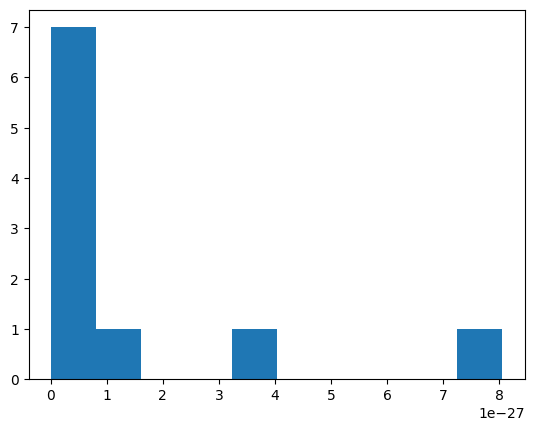

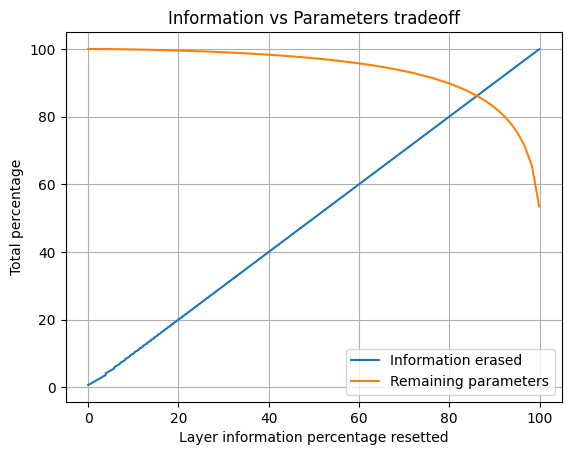

In [26]:
from fisherunlearn import plot_information_parameters_tradeoff
import matplotlib.pyplot as plt

abs_client_information = {}
for key, p in client_information.items():
    abs_client_information[key]=torch.where(p>0,p,torch.zeros_like(p))
    print(torch.sum(p>0).item())
    try:
        plt.hist(p.flatten().numpy())
        plt.show()
    except:
        pass

plot_information_parameters_tradeoff(client_information, "information")

In [27]:
from fisherunlearn import find_informative_params, reset_parameters, UnlearnNet

def run_test(client_information, unlearning_method, unlearning_percentage):
    informative_params = find_informative_params(client_information, unlearning_method, unlearning_percentage)
    num_reset_params = 0
    for indices_tensor in informative_params.values():
        if indices_tensor is not None and indices_tensor.numel() > 0: 
            num_reset_params += indices_tensor.shape[0]

    if num_reset_params != 0:
        reset_model = model_class()
        reset_state_dict = reset_parameters(trained_model, informative_params)
        reset_model.load_state_dict(reset_state_dict)

        retrainer = UnlearnNet(reset_model, informative_params) 
        trainer_function(retrainer, loss_class(), retrain_subsets, eval_subsets, retrain_epochs)
        retrained_model = model_class()
        retrained_model.load_state_dict(retrainer.get_retrained_params())

        reset_params_percentage = num_reset_params / num_total_params * 100
        random_params = find_informative_params(client_information, 'random', reset_params_percentage)

        random_reset_model = model_class()
        random_reset_state_dict = reset_parameters(trained_model.cpu(), random_params)
        random_reset_model.load_state_dict(random_reset_state_dict)

        random_retrainer = UnlearnNet(random_reset_model, random_params)
        trainer_function(random_retrainer, loss_class(), retrain_subsets, eval_subsets, retrain_epochs)
        random_retrained_model = model_class()
        random_retrained_model.load_state_dict(random_retrainer.get_retrained_params())
    else:
        print("No parameters to reset, skipping unlearning and retraining.")
        reset_model = trained_model
        retrained_model = trained_model
        random_reset_model = trained_model
        random_retrained_model = trained_model
        reset_params_percentage = 0.0

    # Execute tests
    extra_results = {}

    extra_results['num_total_params'] = num_total_params
    extra_results['num_reset_params'] = num_reset_params
    extra_results['reset_params_percentage'] = reset_params_percentage

    print(f"Percentage of reset parameters: {reset_params_percentage:.4f}% ({num_reset_params}/{num_total_params})")
    

    eval_test_results = {
        "reset": evaluate_model(reset_model, test_dataset),
        "retrained": evaluate_model(retrained_model, test_dataset),
        "random_reset": evaluate_model(random_reset_model, test_dataset),
        "random_retrained": evaluate_model(random_retrained_model, test_dataset)
    }
    eval_train_results = {
        "reset": evaluate_model(reset_model, train_dataset),
        "retrained": evaluate_model(retrained_model, train_dataset),
        "random_reset": evaluate_model(random_reset_model, train_dataset),
        "random_retrained": evaluate_model(random_retrained_model, train_dataset)
    }

    return eval_test_results, eval_train_results, extra_results

In [28]:
unlearning_method = 'information'
unlearning_percentages = np.linspace(0, 100, num=10).tolist()

acc_eval_test_results = []
acc_eval_train_results = []
acc_extra_results = []

for unlearning_percentage in unlearning_percentages:
    print(f"Running test for unlearning percentage: {unlearning_percentage:.2f}%")
    eval_test_results, eval_train_results, extra_results = run_test(client_information, unlearning_method, unlearning_percentage)
    acc_eval_test_results.append(eval_test_results)
    acc_eval_train_results.append(eval_train_results)
    acc_extra_results.append(extra_results)

eval_test_results = {}
for key in acc_eval_test_results[0].keys():
    eval_test_results[f"{key}__pred"] = np.stack(
        [acc_eval_test_results[i][key]["pred"] for i in range(len(acc_eval_test_results))]
    )
    eval_test_results[f"{key}__loss"] = np.stack(
        [acc_eval_test_results[i][key]["loss"] for i in range(len(acc_eval_test_results))]
    )

with open(os.path.join(test_iter_path, "eval_test_results.npz"), 'wb') as f:
    np.savez(f, **eval_test_results)

eval_train_results = {}
for key in acc_eval_train_results[0].keys():
    eval_train_results[f"{key}__pred"] = np.stack(
        [acc_eval_train_results[i][key]["pred"] for i in range(len(acc_eval_train_results))]
    )
    eval_train_results[f"{key}__loss"] = np.stack(
        [acc_eval_train_results[i][key]["loss"] for i in range(len(acc_eval_train_results))]
    )

with open(os.path.join(test_iter_path, "eval_train_results.npz"), 'wb') as f:
    np.savez(f, **eval_train_results)

extra_results = {}
for key in acc_extra_results[0].keys():
    extra_results[key] = [acc_extra_results[i][key] for i in range(len(acc_extra_results))]

with open(os.path.join(test_iter_path, "extra_results.pkl"), 'wb') as f:
    pickle.dump(extra_results, f)

Running test for unlearning percentage: 0.00%
No parameters to reset, skipping unlearning and retraining.
Percentage of reset parameters: 0.0000% (0/1663370)
Running test for unlearning percentage: 11.11%


Epoch 1/1, Loss: 0.020027071229949713, Val Loss: 0.039720157716566555


Epoch 1/1, Loss: 0.02114426748465671, Val Loss: 0.04796686802859394
Percentage of reset parameters: 0.1798% (2991/1663370)


Running test for unlearning percentage: 22.22%


Epoch 1/1, Loss: 0.025444786284297576, Val Loss: 0.03966517334517378


...

Epoch 1/1, Loss: 0.1978337326097887, Val Loss: 0.07854984526355298


Epoch 1/1, Loss: 0.034203015428935286, Val Loss: 0.04618186756777458
Percentage of reset parameters: 16.1788% (269113/1663370)


Running test for unlearning percentage: 100.00%


Epoch 1/1, Loss: 2.144644288822662, Val Loss: 1.2445411124290564


Epoch 1/1, Loss: 0.12422090438384087, Val Loss: 0.06653671476464623
Percentage of reset parameters: 47.6653% (792850/1663370)
